In [ ]:
# Filtering out the warnings

import warnings

warnings.filterwarnings('ignore')

In [ ]:
# Importing the required libraries

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Read the csv file using 'read_csv'. Please write your dataset location here.

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Linear Regression Assignment/day - day.csv.csv')
df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,01-01-2018,1,0,1,0,1,1,2,14.110847,18.18125,80.5833,10.749882,331,654,985
1,2,02-01-2018,1,0,1,0,2,1,2,14.902598,17.68695,69.6087,16.652113,131,670,801
2,3,03-01-2018,1,0,1,0,3,1,1,8.050924,9.47025,43.7273,16.636703,120,1229,1349
3,4,04-01-2018,1,0,1,0,4,1,1,8.200000,10.60610,59.0435,10.739832,108,1454,1562
4,5,05-01-2018,1,0,1,0,5,1,1,9.305237,11.46350,43.6957,12.522300,82,1518,1600


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     730 non-null    int64  
 1   dteday      730 non-null    object 
 2   season      730 non-null    int64  
 3   yr          730 non-null    int64  
 4   mnth        730 non-null    int64  
 5   holiday     730 non-null    int64  
 6   weekday     730 non-null    int64  
 7   workingday  730 non-null    int64  
 8   weathersit  730 non-null    int64  
 9   temp        730 non-null    float64
 10  atemp       730 non-null    float64
 11  hum         730 non-null    float64
 12  windspeed   730 non-null    float64
 13  casual      730 non-null    int64  
 14  registered  730 non-null    int64  
 15  cnt         730 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.4+ KB


In [ ]:
df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000
mean,365.500000,2.498630,0.500000,6.526027,0.028767,2.995890,0.690411,1.394521,20.319259,23.726322,62.765175,12.763620,849.249315,3658.757534,4508.006849
std,210.877136,1.110184,0.500343,3.450215,0.167266,2.000339,0.462641,0.544807,7.506729,8.150308,14.237589,5.195841,686.479875,1559.758728,1936.011647
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,2.424346,3.953480,0.000000,1.500244,2.000000,20.000000,22.000000
25%,183.250000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,13.811885,16.889713,52.000000,9.041650,316.250000,2502.250000,3169.750000
50%,365.500000,3.000000,0.500000,7.000000,0.000000,3.000000,1.000000,1.000000,20.465826,24.368225,62.625000,12.125325,717.000000,3664.500000,4548.500000
75%,547.750000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,26.880615,30.445775,72.989575,15.625589,1096.500000,4783.250000,5966.000000
max,730.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,35.328347,42.044800,97.250000,34.000021,3410.000000,6946.000000,8714.000000


In [ ]:
df.shape

(730, 16)

In [ ]:
df.isnull().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


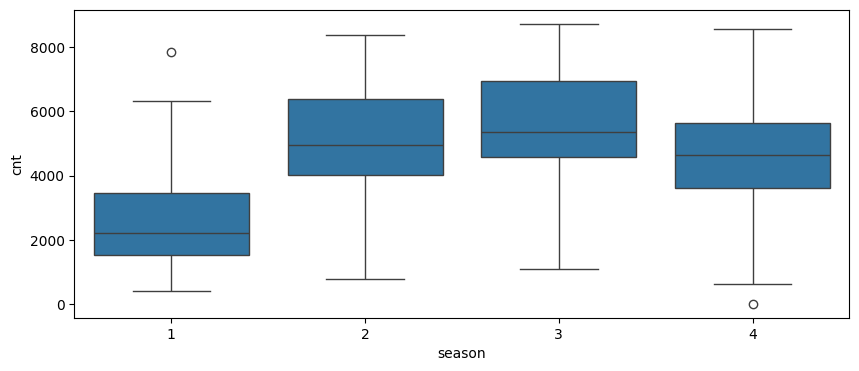

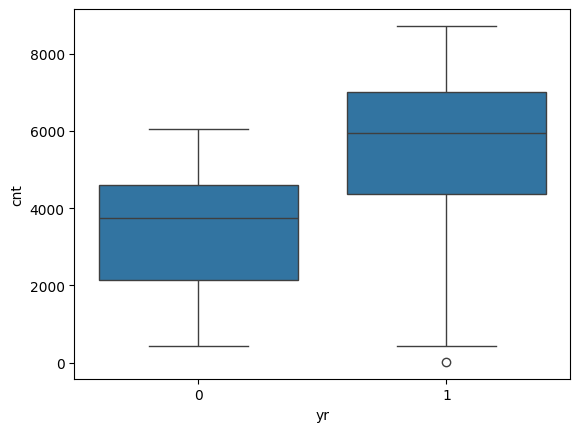

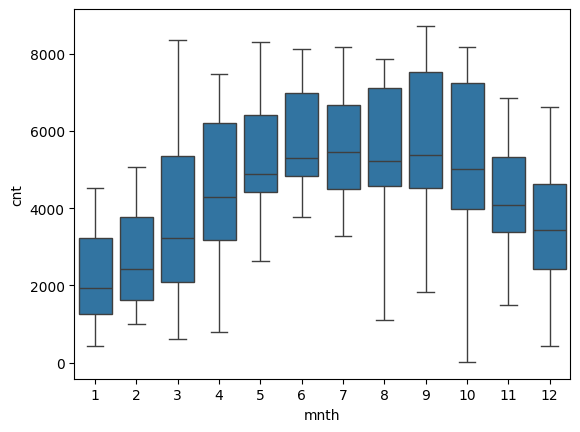

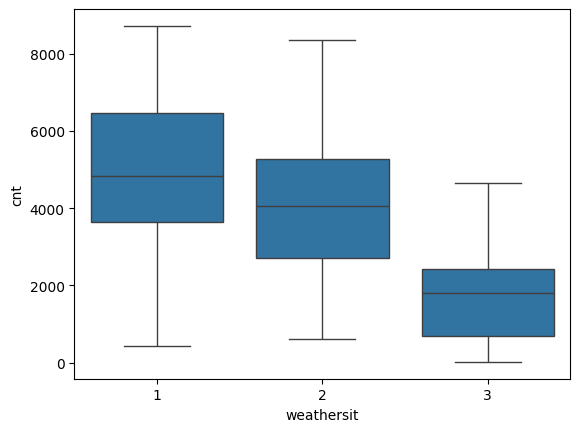

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,4))
sns.boxplot(x='season', y='cnt', data=df)
plt.show()

sns.boxplot(x='yr', y='cnt', data=df)
plt.show()

sns.boxplot(x='mnth', y='cnt', data=df)
plt.show()

sns.boxplot(x='weathersit', y='cnt', data=df)
plt.show()

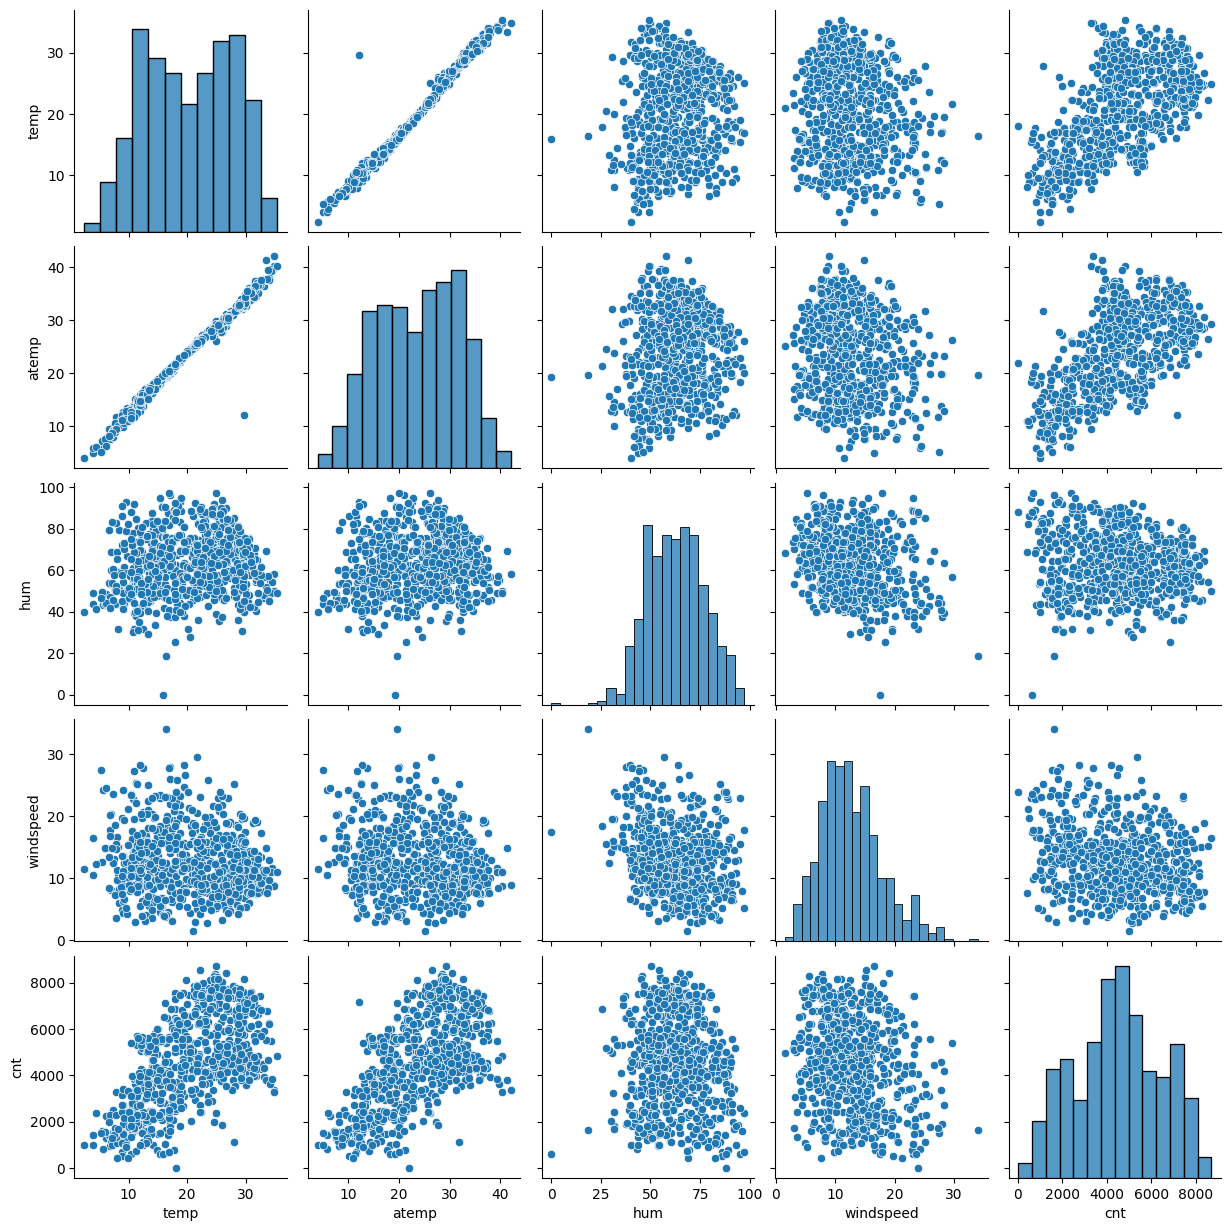

In [ ]:
sns.pairplot(df[['temp', 'atemp', 'hum', 'windspeed', 'cnt']])
plt.show()

In [ ]:
df.drop(['instant', 'dteday', 'atemp', 'casual', 'registered'], axis=1, inplace=True)

In [ ]:
df['season'] = df['season'].map({1: 'spring', 2: 'summer', 3: 'fall', 4: 'winter'})
df['weathersit'] = df['weathersit'].map({1: 'clear', 2: 'mist', 3: 'light_rain_snow', 4: 'heavy_rain_snow'})
df['mnth'] = df['mnth'].map({1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun', 7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'})
df['weekday'] = df['weekday'].map({0:'Sun', 1:'Mon', 2:'Tue', 3:'Wed', 4:'Thu', 5:'Fri', 6:'Sat'})

In [ ]:
#one-hot encoded variables
dummyVars = pd.get_dummies(df[['season', 'mnth', 'weekday', 'weathersit']], drop_first=True, dtype=int)
df = pd.concat([df, dummyVars], axis=1)
df.drop(['season', 'mnth', 'weekday', 'weathersit'], axis=1, inplace=True)

In [ ]:
from sklearn.model_selection import train_test_split
dfTrain, dfTest = train_test_split(df, train_size=0.7, test_size=0.3, random_state=100)

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
numVars = ['temp', 'hum', 'windspeed', 'cnt']
dfTrain[numVars] = scaler.fit_transform(dfTrain[numVars])

In [ ]:
yTrain = dfTrain.pop('cnt')
XTrain = dfTrain

from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm

# Run a baseline RFE to select top 15 features
lm = LinearRegression()
lm.fit(XTrain, yTrain)
rfe = RFE(lm, n_features_to_select=15)
rfe = rfe.fit(XTrain, yTrain)

# Filter columns down to those chosen by RFE
supportedCols = XTrain.columns[rfe.support_]
XTrainRFE = XTrain[supportedCols]

# Build the structural Ordinary Least Squares (OLS) model
XTrainRFECons = sm.add_constant(XTrainRFE)
lrModel = sm.OLS(yTrain, XTrainRFECons).fit()

# Evaluate model summaries
print(lrModel.summary())

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.845
Model:                            OLS   Adj. R-squared:                  0.841
Method:                 Least Squares   F-statistic:                     180.2
Date:                Tue, 23 Jun 2026   Prob (F-statistic):          3.34e-189
Time:                        15:29:06   Log-Likelihood:                 514.72
No. Observations:                 510   AIC:                            -997.4
Df Residuals:                     494   BIC:                            -929.7
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

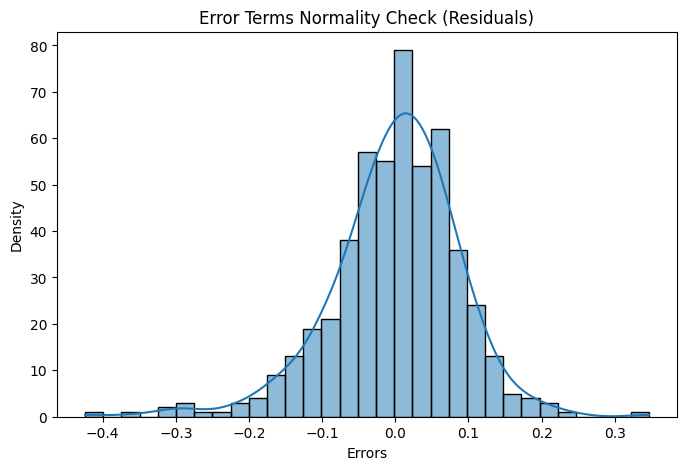

In [20]:
# 1. Predict the target values for the training set
yTrainPred = lrModel.predict(XTrainRFECons)

# 2. Calculate the residuals
res = yTrain - yTrainPred

# 3. Plot the histogram of the error terms
plt.figure(figsize=(8, 5))
sns.histplot(res, kde=True)
plt.title('Error Terms Normality Check (Residuals)')
plt.xlabel('Errors')
plt.ylabel('Density')
plt.show()

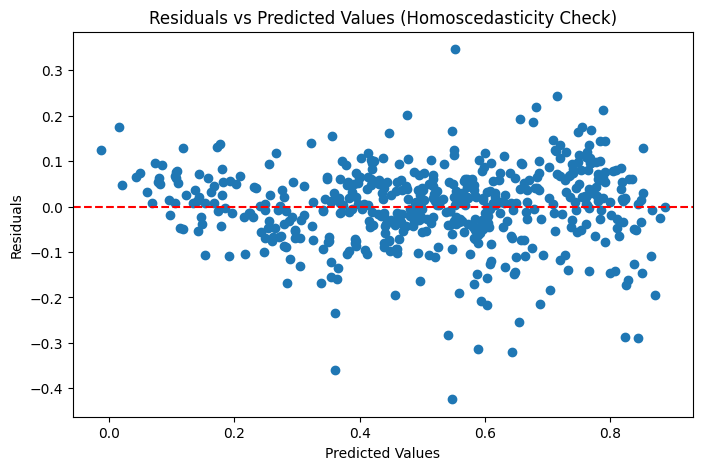

In [21]:
# Plot residuals against predicted values to check for homoscedasticity
plt.figure(figsize=(8, 5))
plt.scatter(yTrainPred, res)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs Predicted Values (Homoscedasticity Check)')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.show()